---
title: Tooling
subtitle: "How I use Claude Code: tool call patterns across coding sessions"
---

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

SCARLET = "#bb0000"
DARK_GRAY = "#333333"
LIGHT_GRAY = "#cccccc"
DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

with open("data/tool-usage.json") as f:
    data = json.load(f)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Session Overview

In [2]:
from IPython.display import HTML, display

s = data["session_stats"]
meta = data["meta"]

cards = f"""<div class="stat-cards">
<div class="stat-card"><div class="stat-value">{s['total_sessions']:,}</div><div class="stat-label">Sessions</div></div>
<div class="stat-card"><div class="stat-value">{meta['total_records']:,}</div><div class="stat-label">Tool Calls</div></div>
<div class="stat-card"><div class="stat-value">{s['median_calls']}</div><div class="stat-label">Median Calls / Session</div></div>
<div class="stat-card"><div class="stat-value">{s['max_calls']}</div><div class="stat-label">Max Calls (Single Session)</div></div>
<div class="stat-card"><div class="stat-value">{s['mean_unique_tools']}</div><div class="stat-label">Avg Unique Tools / Session</div></div>
</div>"""
display(HTML(cards))

## Tool Usage Heatmap

When and how often tools are called, by hour of day and day of week.

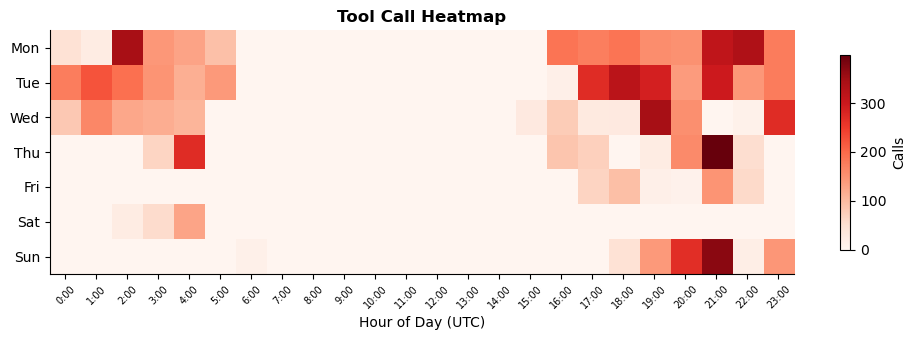

In [3]:
grid = np.zeros((7, 24))
for d in data["heatmap"]:
    grid[d["day_of_week"]][d["hour"]] = d["count"]

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(grid, cmap="Reds", aspect="auto")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h}:00" for h in range(24)], fontsize=7, rotation=45)
ax.set_yticks(range(7))
ax.set_yticklabels(DAY_LABELS)
ax.set_xlabel("Hour of Day (UTC)")
plt.colorbar(im, ax=ax, label="Calls", shrink=0.8)
ax.set_title("Tool Call Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

## Top Tools

The 15 most-used tools, colored by source (built-in vs MCP server).

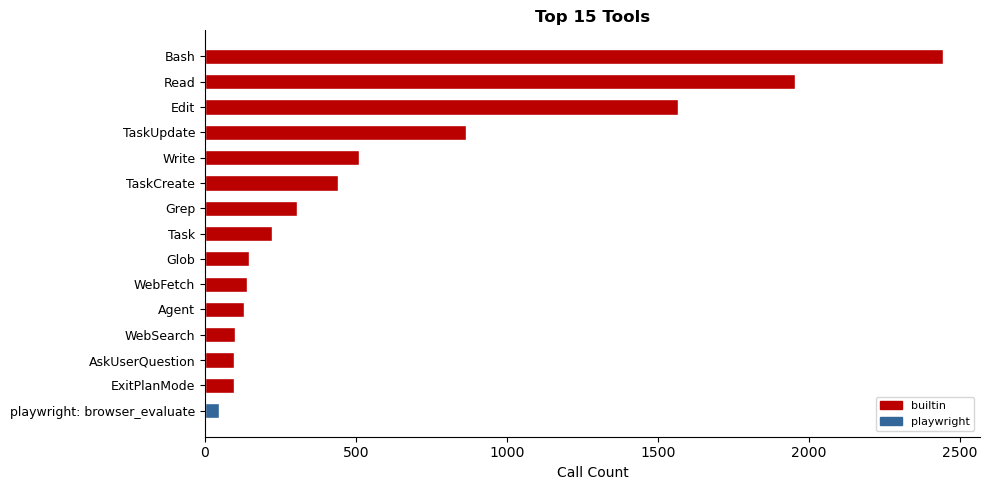

In [4]:
top15 = data["tool_counts"][:15]
names = [t["tool"].replace("mcp__", "").replace("__", ": ") for t in top15]
counts = [t["count"] for t in top15]
sources = [t["mcp_server"] if t["mcp_server"] else "builtin" for t in top15]
unique_sources = list(dict.fromkeys(sources))
cmap = {"builtin": SCARLET}
palette = ["#336699", "#cc9933", "#339966", "#663399", "#cc6633"]
for i, s in enumerate(s for s in unique_sources if s != "builtin"):
    cmap[s] = palette[i % len(palette)]
colors = [cmap[s] for s in sources]

fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(top15))
ax.barh(y, counts, color=colors, height=0.6, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("Call Count")
ax.set_title("Top 15 Tools", fontweight="bold")
ax.invert_yaxis()
handles = [mpatches.Patch(color=cmap[s], label=s) for s in unique_sources]
ax.legend(handles=handles, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## MCP Server Breakdown

Tool calls to each MCP server, broken down by individual tool.

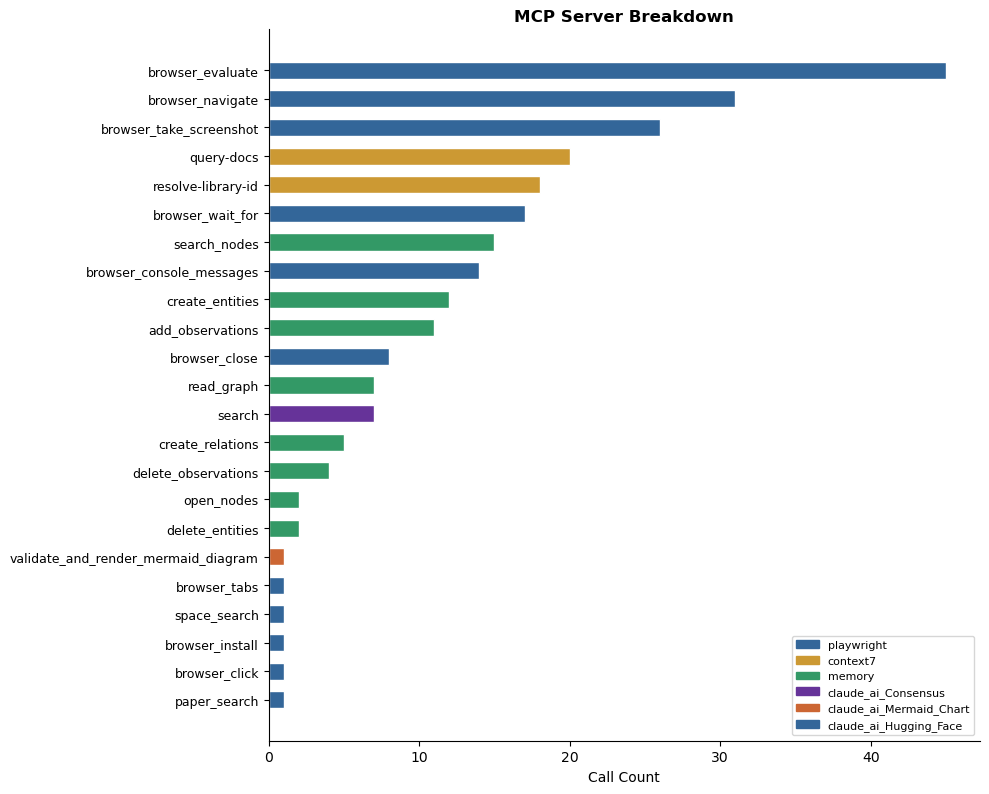

In [5]:
mcp = data["mcp_breakdown"]
mcp_names = [d["tool"].replace(f"mcp__{d['server']}__", "") for d in mcp]
mcp_counts = [d["count"] for d in mcp]
mcp_servers = [d["server"] for d in mcp]
unique_mcp = list(dict.fromkeys(mcp_servers))
mcp_cmap = {s: palette[i % len(palette)] for i, s in enumerate(unique_mcp)}
mcp_colors = [mcp_cmap[s] for s in mcp_servers]

fig, ax = plt.subplots(figsize=(10, max(5, len(mcp) * 0.35)))
y = range(len(mcp))
ax.barh(y, mcp_counts, color=mcp_colors, height=0.6, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(mcp_names, fontsize=9)
ax.set_xlabel("Call Count")
ax.set_title("MCP Server Breakdown", fontweight="bold")
ax.invert_yaxis()
handles = [mpatches.Patch(color=mcp_cmap[s], label=s) for s in unique_mcp]
ax.legend(handles=handles, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## Daily Trend

Total tool calls per day, stacked by source category.

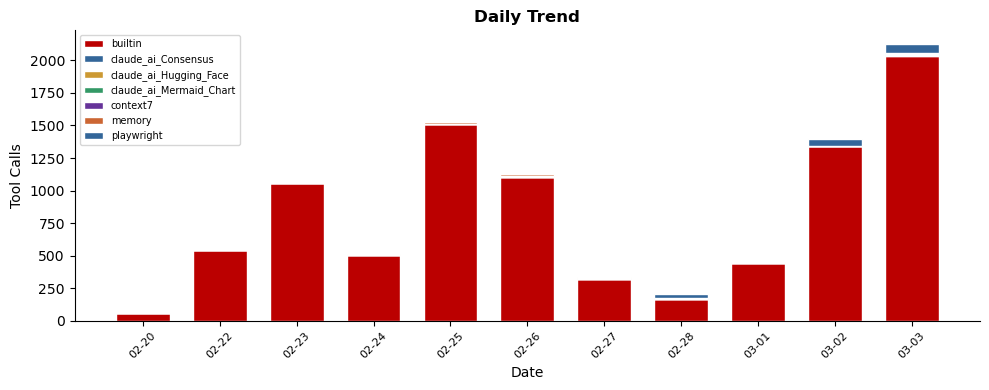

In [6]:
trend = data["daily_trend"]
dates = sorted(set(d["date"] for d in trend))
servers = sorted(set(d["server"] for d in trend))
trend_cmap = {"builtin": SCARLET}
for i, s in enumerate(s for s in servers if s != "builtin"):
    trend_cmap[s] = palette[i % len(palette)]

fig, ax = plt.subplots(figsize=(10, 4))
bottoms = np.zeros(len(dates))
for server in servers:
    vals = []
    for date in dates:
        match = [d for d in trend if d["date"] == date and d["server"] == server]
        vals.append(match[0]["count"] if match else 0)
    ax.bar(range(len(dates)), vals, bottom=bottoms,
           label=server, color=trend_cmap.get(server, LIGHT_GRAY),
           edgecolor="white", width=0.7)
    bottoms += np.array(vals)

ax.set_xticks(range(len(dates)))
ax.set_xticklabels([d[5:] for d in dates], rotation=45, fontsize=8)
ax.set_xlabel("Date")
ax.set_ylabel("Tool Calls")
ax.set_title("Daily Trend", fontweight="bold")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

## Project Breakdown

Tool calls by project — where the work happens.

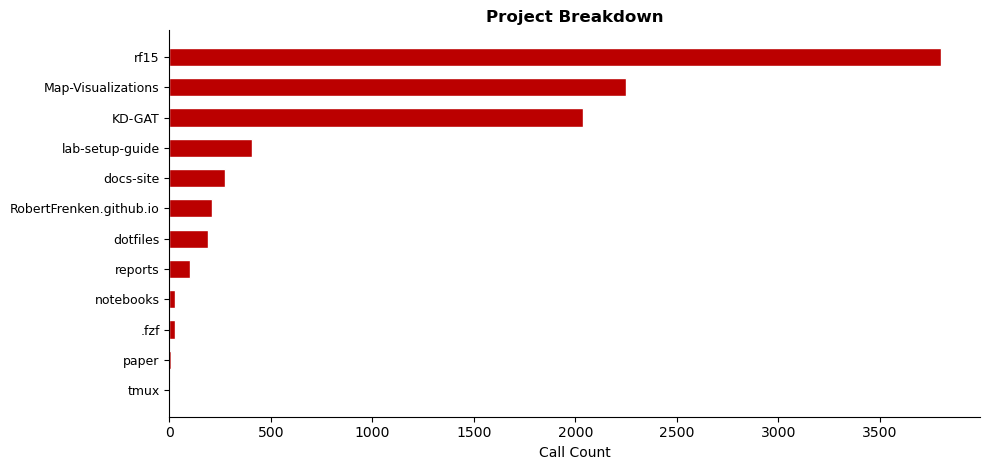

In [7]:
projects = data["project_breakdown"]
proj_names = [p["project"] for p in projects]
proj_counts = [p["count"] for p in projects]

fig, ax = plt.subplots(figsize=(10, max(4, len(projects) * 0.4)))
ax.barh(range(len(projects)), proj_counts, color=SCARLET, height=0.6, edgecolor="white")
ax.set_yticks(range(len(projects)))
ax.set_yticklabels(proj_names, fontsize=9)
ax.set_xlabel("Call Count")
ax.set_title("Project Breakdown", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Knowledge Graph Usage

Calls to the memory MCP server by operation type.

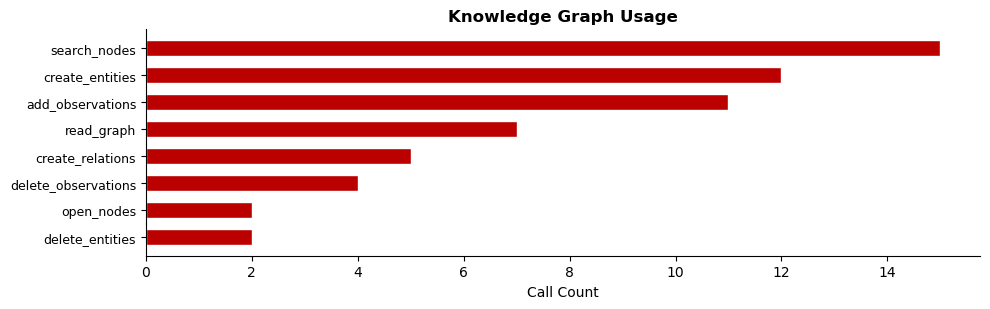

In [8]:
entities = data["entity_access"]
ent_names = [e["entity"].replace("mcp__memory__", "") for e in entities]
ent_counts = [e["count"] for e in entities]

fig, ax = plt.subplots(figsize=(10, max(3, len(entities) * 0.4)))
ax.barh(range(len(entities)), ent_counts, color=SCARLET, height=0.6, edgecolor="white")
ax.set_yticks(range(len(entities)))
ax.set_yticklabels(ent_names, fontsize=9)
ax.set_xlabel("Call Count")
ax.set_title("Knowledge Graph Usage", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()